# GRU sentiment classifier on Rotten Tomatoes

## Imports

In [1]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import defaultdict
import re
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Load dataset and preprocessing

In [2]:
ds = load_dataset('cornell-movie-review-data/rotten_tomatoes')
train_data = ds['train']
test_data = ds['test']

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

def clean_text(text):
    text = text.lower()                    
    text = re.sub(r'<.*?>', '', text)     
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)


## Tokenization, vocabulary and datasets

In [3]:
def build_vocab(texts):
    vocab = defaultdict(lambda: len(vocab))
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    for text in texts:
        for word in re.findall(r'\w+', text.lower()):
            vocab[word]
    return vocab

vocab = build_vocab(train_df['text'])

def encode_text(text, vocab):
    return [vocab.get(word, vocab['<UNK>']) for word in re.findall(r'\w+', text.lower())]

train_df['encoded'] = train_df['text'].apply(lambda x: encode_text(x, vocab))
test_df['encoded'] = test_df['text'].apply(lambda x: encode_text(x, vocab))

max_len = max(train_df['encoded'].apply(len).max(), test_df['encoded'].apply(len).max())

def pad_sequence(seq, max_len):
    return seq + [vocab['<PAD>']] * (max_len - len(seq))

train_df['padded'] = train_df['encoded'].apply(lambda x: pad_sequence(x, max_len))
test_df['padded'] = test_df['encoded'].apply(lambda x: pad_sequence(x, max_len))

In [4]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx])

train_labels = train_df['label'].values
test_labels = test_df['label'].values

train_dataset = SentimentDataset(train_df['padded'].values, train_labels)
test_dataset = SentimentDataset(test_df['padded'].values, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Model definition GRU

In [5]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, max_len):
        super(GRUSentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.max_len = max_len

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

vocab_size = len(vocab)
embed_dim = 100
hidden_dim = 64
output_dim = 2

model = GRUSentimentModel(vocab_size, embed_dim, hidden_dim, output_dim, max_len)
print(model)

GRUSentimentModel(
  (embedding): Embedding(17993, 100, padding_idx=0)
  (gru): GRU(100, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


## Training loop 

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 15
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0
best_model_state = None

for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_model_state = model.state_dict()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")


  7%|▋         | 1/15 [00:02<00:40,  2.90s/it]

Epoch 1/15, Train Loss: 0.6936, Train Accuracy: 0.5004, Val Loss: 0.6930, Val Accuracy: 0.5000


 13%|█▎        | 2/15 [00:05<00:36,  2.83s/it]

Epoch 2/15, Train Loss: 0.6931, Train Accuracy: 0.5066, Val Loss: 0.6933, Val Accuracy: 0.5009


 20%|██        | 3/15 [00:08<00:33,  2.83s/it]

...

Epoch 13/15, Train Loss: 0.0299, Train Accuracy: 0.9919, Val Loss: 1.2791, Val Accuracy: 0.7289


 93%|█████████▎| 14/15 [00:40<00:02,  2.88s/it]

Epoch 14/15, Train Loss: 0.0262, Train Accuracy: 0.9925, Val Loss: 1.1060, Val Accuracy: 0.7242


100%|██████████| 15/15 [00:43<00:00,  2.87s/it]

Epoch 15/15, Train Loss: 0.0265, Train Accuracy: 0.9916, Val Loss: 1.2478, Val Accuracy: 0.7317


## Plots: validation loss and accuracy over epochs

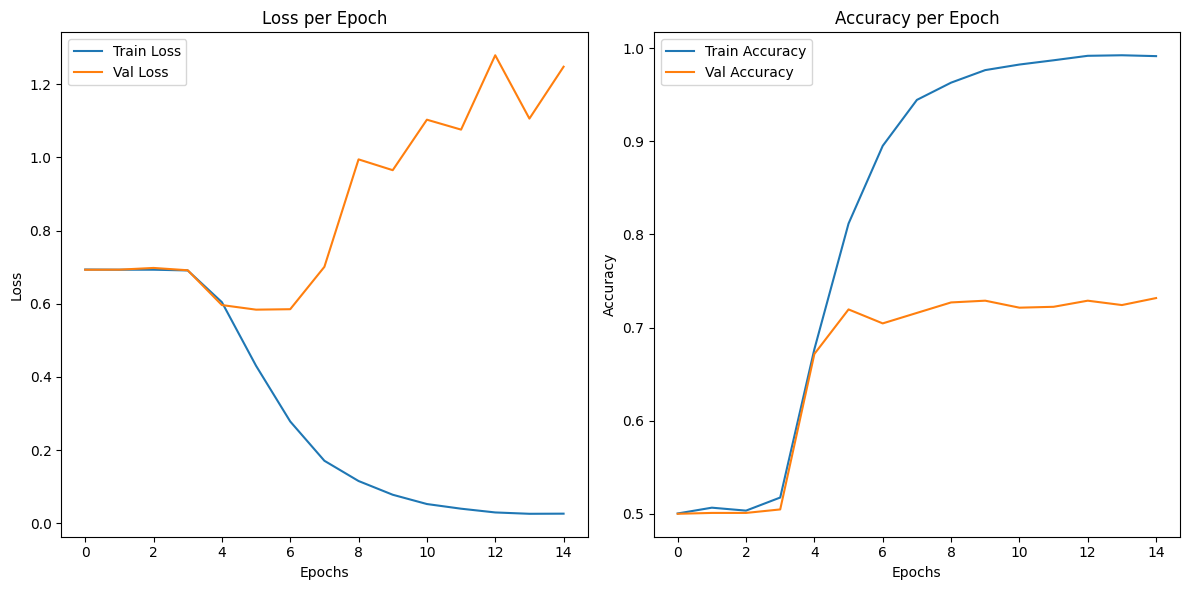

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss per Epoch')

plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_accuracies, label='Train Accuracy')
plt.plot(range(epochs), val_accuracies, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy per Epoch')

plt.tight_layout()
plt.show()

## Load best checkpoint and evaluate on test set

In [8]:
model.load_state_dict(best_model_state)
model.eval()
test_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = correct / total
print(f"Best Checkpoint Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Best Checkpoint Test Loss: 1.2478, Test Accuracy: 0.7317


## Analysis
The model clearly learns the training data very quickly: training accuracy rises from ~50% to ~99% over 15 epochs, and training loss drops steadily. However, validation accuracy only improves up to ~73–74%, and validation loss starts increasing after around epoch 9–10. This indicates overfitting: the model memorizes the training examples but struggles to generalize to unseen data.

The best checkpoint achieves 73.36% accuracy on the test set, which reflects the model’s realistic performance. To improve results, the model could benefit from Dropout or L2 regularization to reduce overfitting, pretrained embeddings to better capture semantic meaning, and possibly a bidirectional GRU or LSTM to understand context from both directions. Early stopping could also prevent the model from overtraining in later epochs. If we were working with very short texts, a CNN could be effective at capturing local patterns, but for full-sentence sentiment analysis, a properly regularized GRU or LSTM is more suitable because it can better capture long-range dependencies and context.